/home/seongyoon/anaconda3/envs/fal/lib/python3.7/site-packages/ipykernel_launcher.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


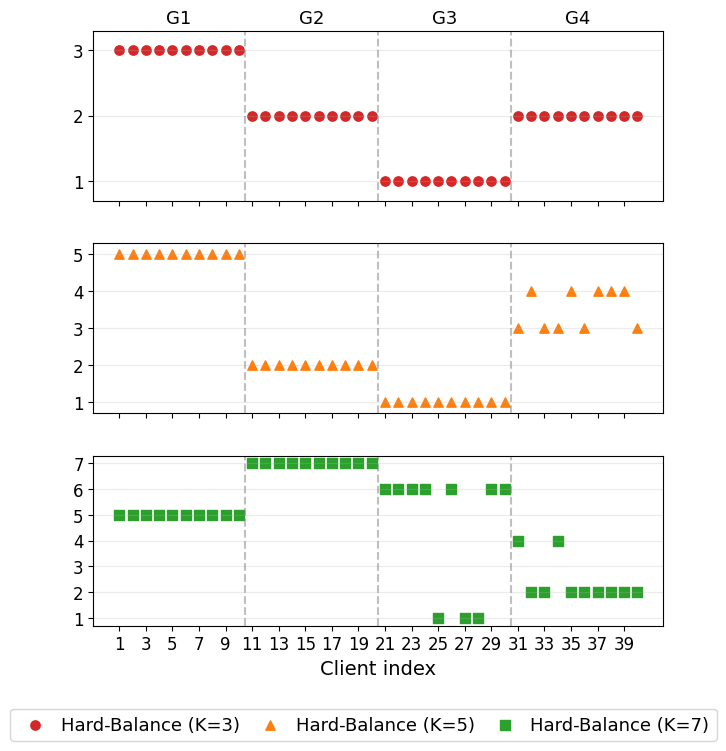

In [4]:
import matplotlib.pyplot as plt

assign_k3 = {1: 3, 2: 3, 3: 3, 4: 3, 5: 3, 6: 3, 7: 3, 8: 3, 9: 3, 10: 3, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 2, 20: 2, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2}

assign_k5 = {1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5, 8: 5, 9: 5, 10: 5, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 2, 20: 2, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 3, 32: 4, 33: 3, 34: 3, 35: 4, 36: 3, 37: 4, 38: 4, 39: 4, 40: 3}

assign_k7 = {1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5, 8: 5, 9: 5, 10: 5, 11: 7, 12: 7, 13: 7, 14: 7, 15: 7, 16: 7, 17: 7, 18: 7, 19: 7, 20: 7, 21: 6, 22: 6, 23: 6, 24: 6, 25: 1, 26: 6, 27: 1, 28: 1, 29: 6, 30: 6, 31: 4, 32: 2, 33: 2, 34: 4, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2}

clients = list(range(1, 41))

color_k3 = "#d62728"  # red
color_k5 = "#ff7f0e"  # orange
color_k7 = "#2ca02c"  # green

# --- 폰트 크게 세팅 (왼쪽 figure와 비슷하게) ---
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})

# 왼쪽 PFL figure와 비슷한 세로 비율로 맞춤
fig, axes = plt.subplots(
    3, 1,
    figsize=(7.5, 8.5),
    sharex=True,
    sharey=False,
    gridspec_kw={"hspace": 0.25}   # 패널 간 간격은 적당히만
)

settings = [
    (assign_k3, "Hard-Balance (K=3)", color_k3, "o"),
    (assign_k5, "Hard-Balance (K=5)", color_k5, "^"),
    (assign_k7, "Hard-Balance (K=7)", color_k7, "s"),
]

for ax, (assign, label, color, marker) in zip(axes, settings):
    ys = [assign[c] for c in clients]
    ax.scatter(
        clients, ys,
        color=color, marker=marker,
        s=45,              # 마커 사이즈 살짝 키움
        label=label
    )

    # 그룹 경계
    for boundary in [10.5, 20.5, 30.5]:
        ax.axvline(boundary, linestyle="--", color="gray", alpha=0.5)

    # 각 K별 y-범위/틱
    y_min, y_max = min(ys), max(ys)
    ax.set_ylim(y_min - 0.3, y_max + 0.3)
    ax.set_yticks(range(y_min, y_max + 1))

    ax.grid(axis="y", alpha=0.25)

# x/y 라벨
axes[-1].set_xlabel("Client index")
# fig.text(
#     0.02, 0.5, "Hard cluster index",
#     va="center", rotation="vertical"
# )

# G1~G4 라벨 (맨 위 축의 x축 위쪽에)
ax_top = axes[0]
for x_pos, g_name in zip([5.5, 15.5, 25.5, 35.5], ["G1", "G2", "G3", "G4"]):
    ax_top.text(
        x_pos, 1.02, g_name,
        transform=ax_top.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=13
    )

xticks = list(range(1, 41, 2))
plt.xticks(xticks)

# ─ 공통 legend 를 아래로 (왼쪽 figure처럼) ─
all_handles = []
all_labels = []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

fig.legend(
    all_handles, all_labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.04),
    frameon=True,
    columnspacing=0.7,   # 🔹 컬럼 간 간격(기본 2.0 정도) → 줄이기
    handletextpad=0.4,   # 🔹 마커와 텍스트 사이 간격 줄이기
    borderaxespad=0.2,   # 🔹 legend와 플롯 사이 간격
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18, left=0.14)  # legend·ylabel 공간
plt.savefig("hard_balance_cluster_assignment_3x1_for_subfigure.pdf",
            dpi=300, bbox_inches="tight")
plt.show()
